<p style="background-color:black; font-family:calibri; color:white; font-size:250%; text-align:center; border-radius:20px 50px;">Capstone Project |Credit Card Usage Segmentation</p>

<div style="border-radius:10px; padding: 15px; font-size:120%; text-align:left">

<h3 align="left"><font color=black>Problem:</font></h3>

In this project, we develop comprehensive unsupervised learning models to accurately segment credit card customers based on their spending and payment behaviors. By utilizing these models, the institution aims to improve targeted marketing, risk assessment, and overall customer relationship management.

<div style="border-radius:10px; padding: 15px; font-size:100%; text-align:left">

<h3 align="left"><font color=black>Objectives:</font></h3>

* __Explore the Dataset__: Uncover patterns, distributions, and relationships within the data.
* __Conduct Extensive Exploratory Data Analysis (EDA)__: Scaling numerical features
* __Preprocessing Steps__:
  - Drop non-numeric and irrelevant column
  - Address missing values
  - Encode categorical variables
* __Model Building__:
 -  Implement PCA and t-SNE for visualizing high-dimensional data in 2D space.
 -  Evaluate various unsupervised learning algorithms including K-Means and Agglomerative Clustering.
 -  Create clear and informative visualizations using libraries like matplotlib and seaborn to communicate data insights and clustering results.
* __Evaluate and Compare Model Performance__: Use appropriate metrics such as silhouette score or inertia to assess clustering quality.

<a id="contents_tabel"></a>    
<div style="border-radius:10px; padding: 15px;font-size:115%; text-align:left">

<h3 align="left"><font color=black>Table of Contents:</font></h3>
    
* [Step 1 | Import Libraries](#import)
* [Step 2 | Read Dataset](#read)
* [Step 3 | Dataset Overview](#overview)
* [Step 4 | Data Preprocessing](#preprocessing)
* [Step 5 | EDA](#eda)
* [Step 6 | DIMENSIONALITY REDUCTION (PCA & t-SNE)](PCA)
* [Step 7 |  MODEL SELECTION AND EVALUATION ](#evaluation)

## Step 1: Importing Libraries

In [18]:
# Load and explore data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import warnings
warnings.filterwarnings("ignore")

## Step 2: Read Dataset

In [21]:
cred_card_Usage= pd.read_csv("C:\\Users\\rafee\\Downloads\\Capstone Project Credit_Card Usage Segmentation\\Customer Data.csv")
cred_card_Usage.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [23]:
#Understand data distribution (mean, std, min, max, quartiles)
cred_card_Usage.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


## Step 3: Dataset Overview

In [26]:
# Display a concise summary of the dataframe
cred_card_Usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [28]:
print(cred_card_Usage["BALANCE"].min())
print(cred_card_Usage["BALANCE"].max())
print(cred_card_Usage["BALANCE"].mean())

0.0
19043.13856
1564.4748276781006


#### Step 3.1 Dataset Basic Information

In [31]:
cred_card_Usage.shape

(8950, 18)

In [33]:
cred_card_Usage.columns

Index(['CUST_ID', 'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES',
       'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE',
       'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY',
       'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY',
       'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS',
       'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE'],
      dtype='object')

In [35]:
# Drop rows with missing values (NaN)
cred_card_Usage= cred_card_Usage.dropna()
cred_card_Usage.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.00,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.25,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.00,0,12,7500.0,622.066742,627.284787,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.00,0,1,1200.0,678.334763,244.791237,0.000000,12
5,C10006,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,0.00,0,8,1800.0,1400.057770,2407.246035,0.000000,12


## Step 4: Data Preprocessing

#### Data Preprocessing: Handle missing values, apply appropriate scaling techniques for numerical variables, and perform any necessary feature engineering.

In [39]:
# Make a copy of the original DataFrame for preprocessing
cred_card_Usage_clean =cred_card_Usage.copy()

In [41]:
# Impute missing values:
# For 'MINIMUM_PAYMENTS', use the median
cred_card_Usage_clean['MINIMUM_PAYMENTS'] = cred_card_Usage_clean['MINIMUM_PAYMENTS'].fillna(cred_card_Usage_clean['MINIMUM_PAYMENTS'].median())

# For 'CREDIT_LIMIT', use the mean (only 1 missing value)
cred_card_Usage_clean['CREDIT_LIMIT'] = cred_card_Usage_clean['CREDIT_LIMIT'].fillna(cred_card_Usage_clean['CREDIT_LIMIT'].mean())

# Create new features (Feature Engineering)
cred_card_Usage_clean['BALANCE_TO_LIMIT_RATIO'] = cred_card_Usage_clean['BALANCE'] /cred_card_Usage_clean['CREDIT_LIMIT']
cred_card_Usage_clean['TOTAL_SPEND'] = cred_card_Usage_clean['PURCHASES'] +cred_card_Usage_clean['CASH_ADVANCE']

In [43]:
# Drop ID column if present
# Drop non-numeric and irrelevant column
if 'CUST_ID' in cred_card_Usage_clean.columns:
    cred_card_Usage_clean.drop(columns=['CUST_ID'], inplace=True)
cred_card_Usage_clean.isnull().sum()

cred_card_Usage_clean.dropna(inplace=True)

In [45]:
# Scale the data using StandardScaler
scaler = StandardScaler()
cred_card_Usage_scaled = pd.DataFrame(scaler.fit_transform(cred_card_Usage_clean), columns =cred_card_Usage_clean.columns)

cred_card_Usage.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.00,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.25,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.00,0,12,7500.0,622.066742,627.284787,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.00,0,1,1200.0,678.334763,244.791237,0.000000,12
5,C10006,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,0.00,0,8,1800.0,1400.057770,2407.246035,0.000000,12


## Step 5: Exploratory Data Analysis (EDA)

#### Conduct comprehensive EDA using visualization techniques to understand feature distributions and relationships within the credit card data.

<Figure size 1500x1000 with 0 Axes>

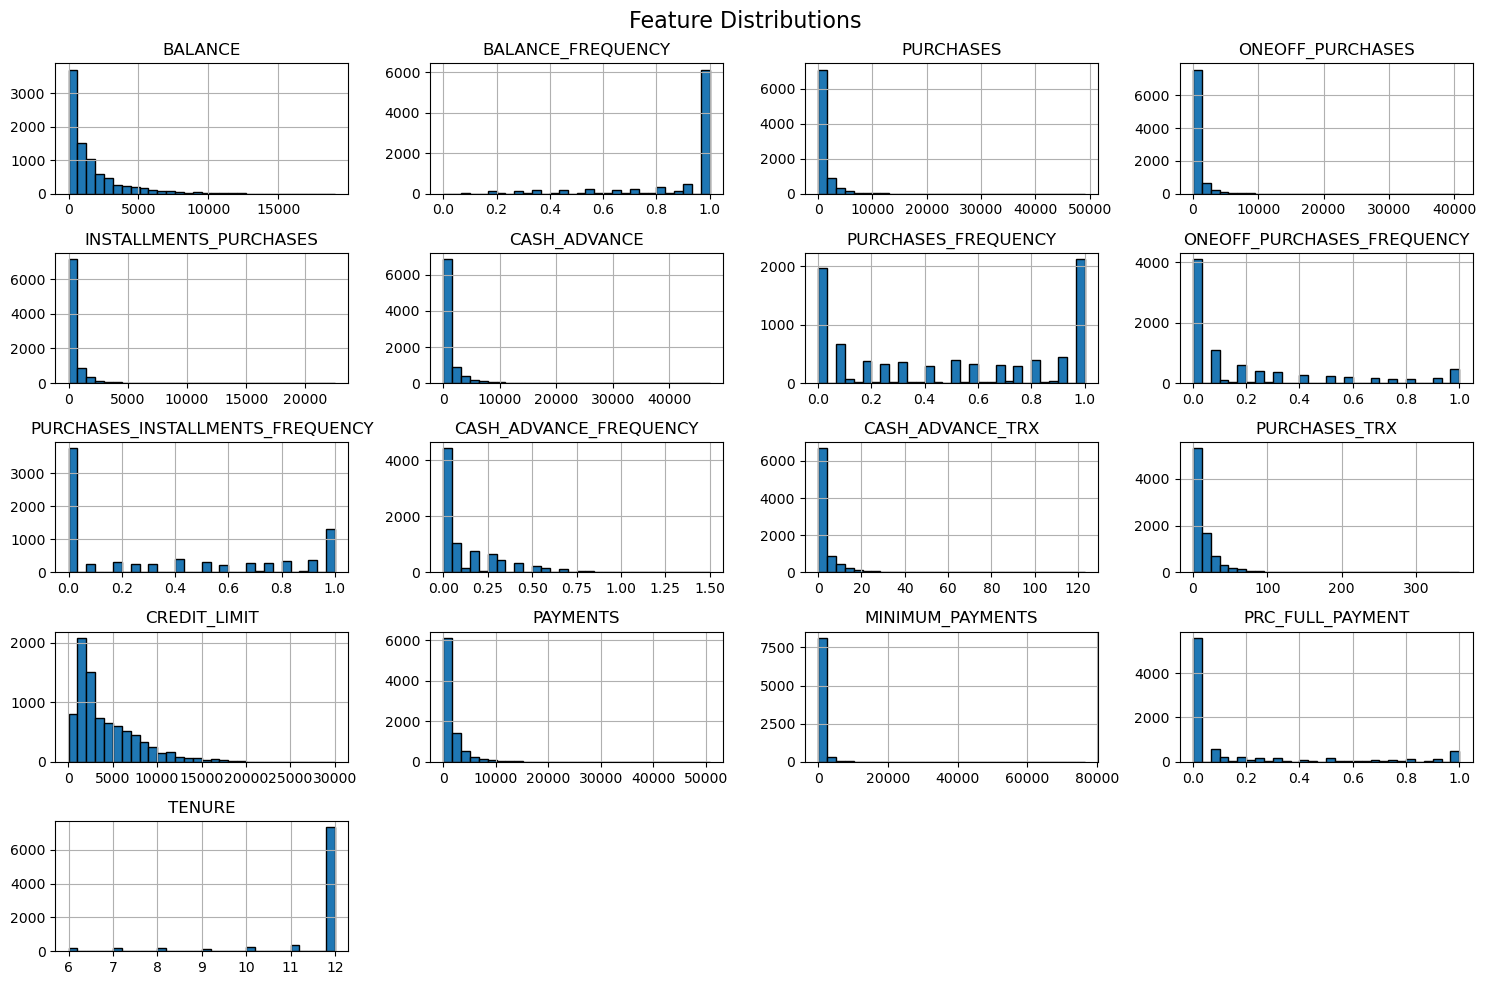

In [49]:
#Scaling numerical features
#scaler = StandardScaler()
#cred_card_Usage_scaled = pd.DataFrame(scaler.fit_transform(cred_card_Usage_scaled))

# Visualization: Histograms for feature distributions
plt.figure(figsize=(15, 10))
cred_card_Usage.hist(bins=30, figsize=(15, 10), edgecolor='black')
plt.suptitle('Feature Distributions', fontsize=16)
plt.tight_layout()
plt.show()

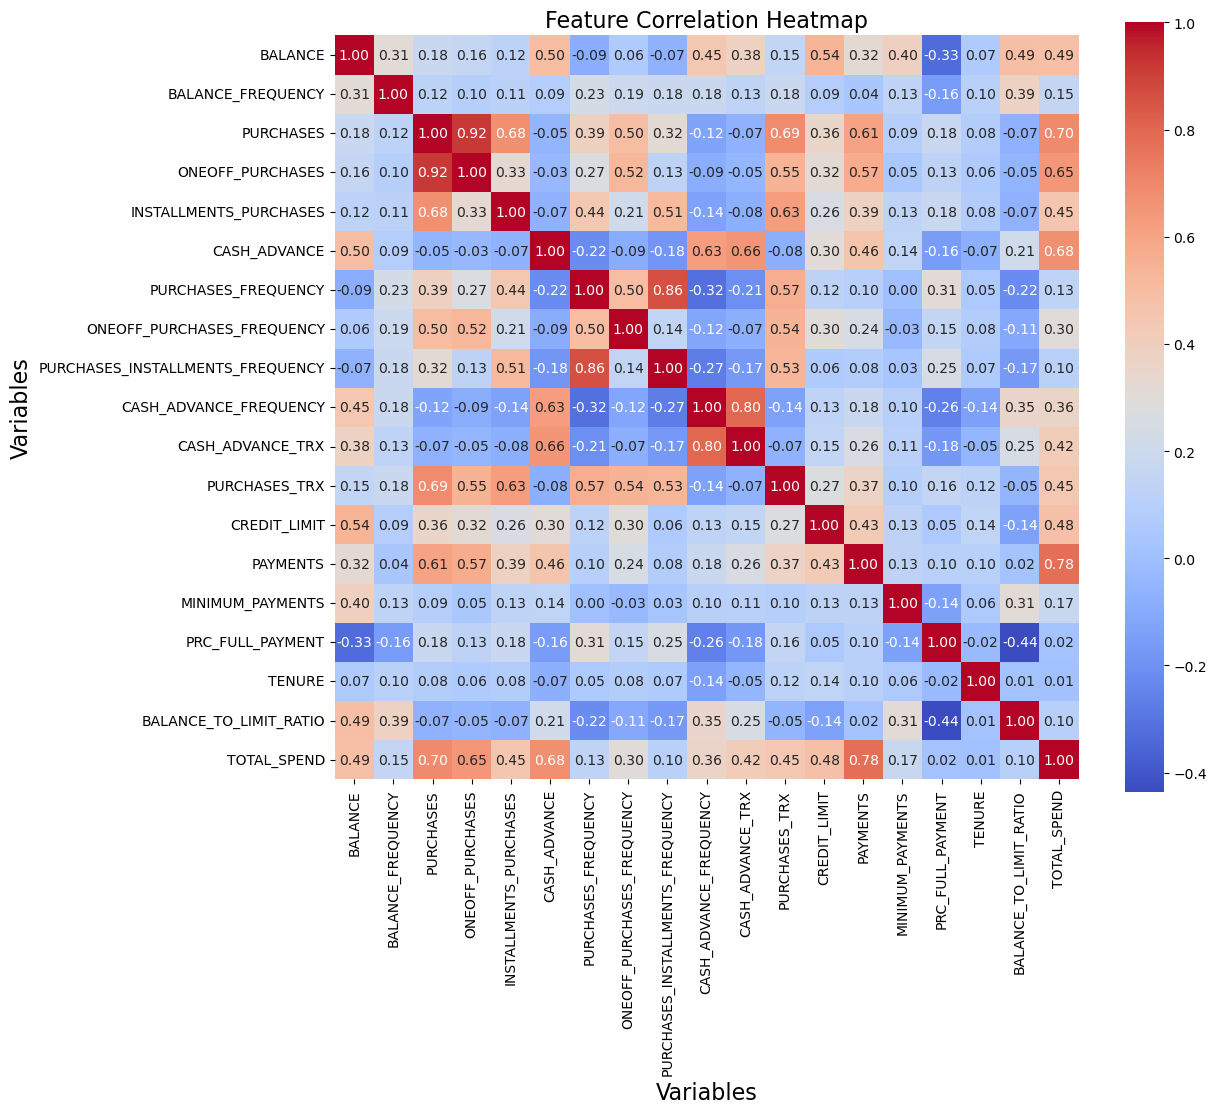

In [50]:
# Visualization: Correlation heatmap
corr_matrix = cred_card_Usage.corr
plt.figure(figsize=(12, 10))
sns.heatmap(cred_card_Usage_scaled.corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.xlabel('Variables',fontsize=16)
plt.ylabel('Variables',fontsize=16)
plt.title('Feature Correlation Heatmap', fontsize=16)
plt.show()

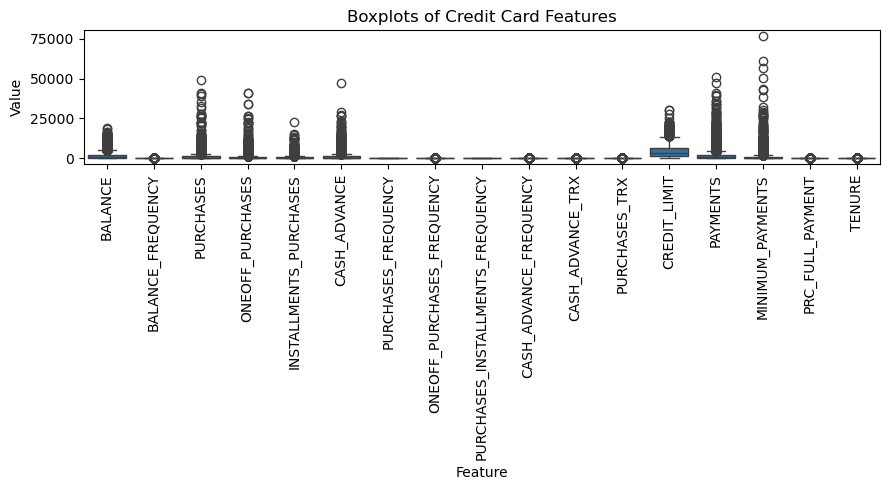

In [51]:
# Drop CUST_ID if present
if 'CUST_ID' in cred_card_Usage.columns:
    cred_card_Usage.drop(columns=['CUST_ID'], inplace=True)

# Create boxplots for numerical columns
plt.figure(figsize=(9,5))
cred_card_Usage_melted = cred_card_Usage.melt(var_name="Feature", value_name="Value")
sns.boxplot(x="Feature", y="Value", data=cred_card_Usage_melted)
plt.xticks(rotation=90)
plt.title("Boxplots of Credit Card Features")
plt.tight_layout()
plt.show()

## Step 6: DIMENSIONALITY REDUCTION (PCA & t-SNE)

#### Implement PCA and t-SNE for visualizing high-dimensional data in 2D space.

In [55]:
# Standard scaling
scaler = StandardScaler()
cred_card_Usage_scaled = scaler.fit_transform(cred_card_Usage)

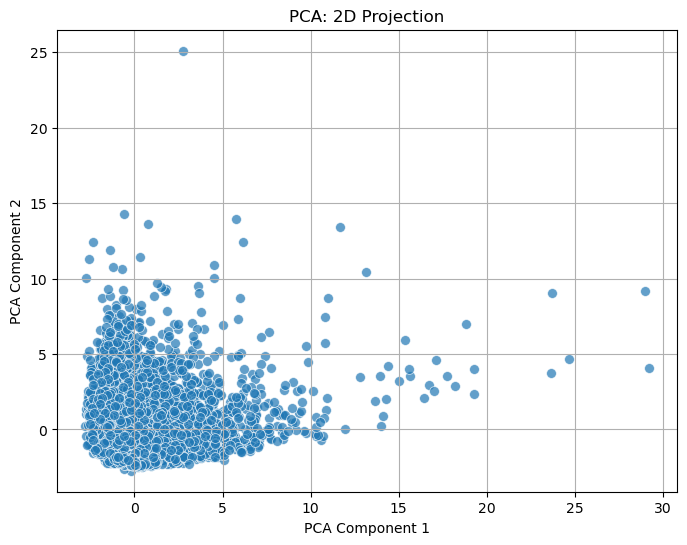

In [57]:
# PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(cred_card_Usage_scaled)

# Plot PCA
plt.figure(figsize=(8, 6))
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], s=50, alpha=0.7)
plt.title('PCA: 2D Projection')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.grid(True)
plt.show()

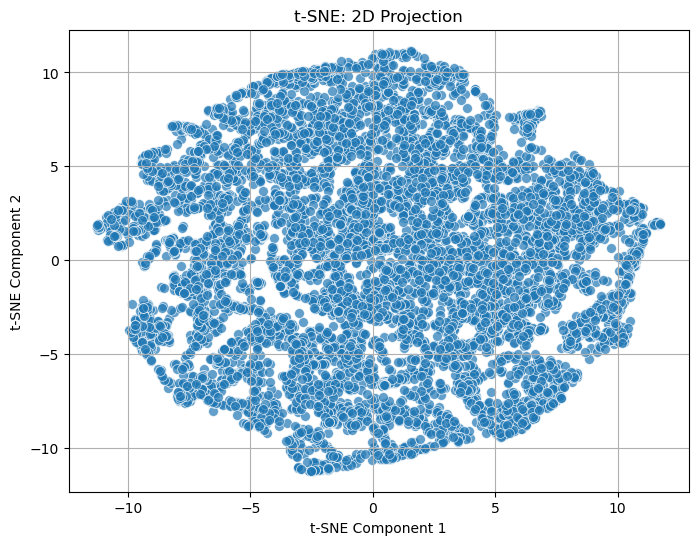

In [61]:
# t-SNE
tsne = TSNE(n_components=2, perplexity=30, max_iter=300, random_state=42)
tsne_result = tsne.fit_transform(cred_card_Usage_scaled)

# Plot t-SNE
plt.figure(figsize=(8, 6))
sns.scatterplot(x=tsne_result[:, 0], y=tsne_result[:, 1], s=50, alpha=0.7)
plt.title('t-SNE: 2D Projection')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.grid(True)
plt.show()

## Step 7: MODEL SELECTION AND EVALUATION

#### Model Selection: Evaluate various unsupervised learning algorithms including K-Means and Agglomerative Clustering

In [64]:
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans_labels = kmeans.fit_predict(cred_card_Usage_scaled)

agglo = AgglomerativeClustering(n_clusters=5)
agglo_labels = agglo.fit_predict(cred_card_Usage_scaled)

# Silhouette Scores
kmeans_silhouette = silhouette_score(cred_card_Usage_scaled, kmeans_labels)
agglo_silhouette = silhouette_score(cred_card_Usage_scaled, agglo_labels)

print(f"KMeans Silhouette Score: {kmeans_silhouette:.4f}")
print(f"Agglomerative Clustering Silhouette Score: {agglo_silhouette:.4f}")


KMeans Silhouette Score: 0.1903
Agglomerative Clustering Silhouette Score: 0.1796


### Use appropriate metrics such as silhouette score or inertia to assess clustering quality.

[0.20816059401067916]
[0.20816059401067916, 0.24709726016009056]
[0.20816059401067916, 0.24709726016009056, 0.1970448976486613]
[0.20816059401067916, 0.24709726016009056, 0.1970448976486613, 0.1920763262167226]
[0.20816059401067916, 0.24709726016009056, 0.1970448976486613, 0.1920763262167226, 0.20769698306515985]
[0.20816059401067916, 0.24709726016009056, 0.1970448976486613, 0.1920763262167226, 0.20769698306515985, 0.22026967649821463]
[0.20816059401067916, 0.24709726016009056, 0.1970448976486613, 0.1920763262167226, 0.20769698306515985, 0.22026967649821463, 0.22714277002964114]
[0.20816059401067916, 0.24709726016009056, 0.1970448976486613, 0.1920763262167226, 0.20769698306515985, 0.22026967649821463, 0.22714277002964114, 0.23193868740057688]
[0.20816059401067916, 0.24709726016009056, 0.1970448976486613, 0.1920763262167226, 0.20769698306515985, 0.22026967649821463, 0.22714277002964114, 0.23193868740057688, 0.21420697552058446]


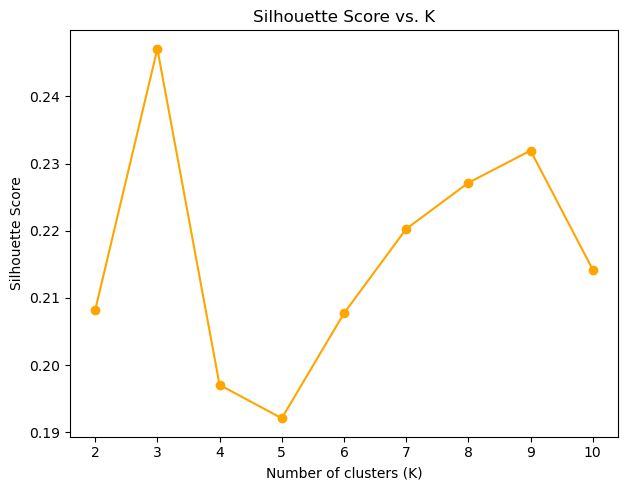

In [66]:
# Determine optimal number of clusters using Elbow Method (Inertia) and Silhouette Score
inertia = []
silhouette_scores = []
K_range = range(2, 11)  # Typically we test between 2 and 10 clusters

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(cred_card_Usage_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(cred_card_Usage_scaled, kmeans.labels_))
    print(silhouette_scores)

# Plot Inertia
plt.figure(figsize=(12, 5))
# Plot Silhouette Score
plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_scores, marker='o', color='orange')
plt.title('Silhouette Score vs. K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

In [78]:
print("Inertia (WCSS):", kmeans.inertia_)

Inertia (WCSS): 146811.99999999994


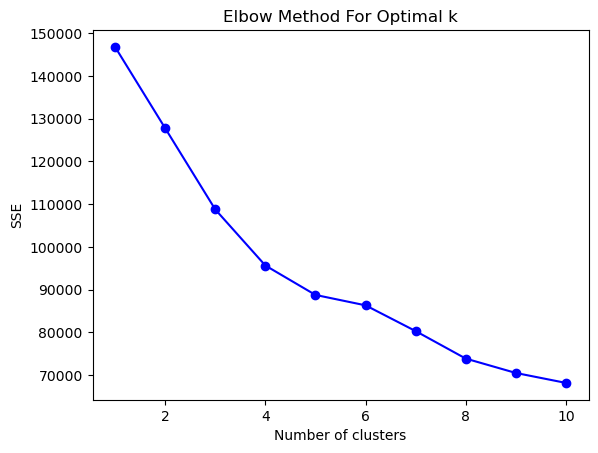

In [82]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cred_card_Usage_scaled)
# Elbow method to determine k
sse = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(X_scaled)
    sse.append(kmeans.inertia_)

plt.figure()
plt.plot(K, sse, 'bo-')
plt.xlabel('Number of clusters')
plt.ylabel('SSE')
plt.title('Elbow Method For Optimal k')
plt.show() 

# Conclusion:

- Successfully segmented credit card users using unsupervised learning (K-Means & Agglomerative Clustering).

- Identified distinct customer groups based on spending habits, credit usage, and payment behavior.

- PCA and t-SNE helped visualize high-dimensional data and validated cluster separation.

- Best-performing model chosen using Silhouette Score and visual analysis.

- Key insights:

 Cluster 1: High spenders with consistent payments — ideal for premium offers.

 Cluster 2: Low usage, low balance — may benefit from engagement strategies.

 Cluster 3: High revolving balance, low payments — potential credit risk, needs monitoring.

- Enables targeted marketing, personalized service, and proactive risk management

<h2 align="left"><font color='black'>Best Regards!</font></h2>